# setting things up

In [1]:
import time
import matplotlib.pyplot as plt
import scipy.special as sp
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from chebtucker import build_chebtucker, TuckerOptions, compute_tools

In [2]:
def marginal_2d_mc(f, d, dims, grid_points=200, n_mc=20_000, key=None,
                   domain=(-1.0, 1.0), batch_size=5_000):
    if key is None:
        key = jax.random.PRNGKey(0)

    i, j = dims
    if i == j:
        raise ValueError("dims must contain two distinct coordinates")
    if not (0 <= i < d and 0 <= j < d):
        raise ValueError("dims must be valid coordinate indices")

    a, b = domain
    xs = jnp.linspace(a, b, grid_points)
    ys = jnp.linspace(a, b, grid_points)
    X, Y = jnp.meshgrid(xs, ys, indexing="ij")

    # Flatten the grid so we can evaluate in chunks.
    grid_flat = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    n_grid = grid_flat.shape[0]

    # Monte Carlo samples for the remaining coordinates
    key, subkey = jax.random.split(key)
    others_dim = d - 2
    if others_dim > 0:
        U = jax.random.uniform(
            subkey,
            shape=(n_mc, others_dim),
            minval=a,
            maxval=b,
        )
        volume_factor = (b - a) ** others_dim
    else:
        U = jnp.zeros((n_mc, 0))
        volume_factor = 1.0

    def eval_chunk(chunk_xy):
        m = chunk_xy.shape[0]
        # Build full inputs of shape (m * n_mc, d)
        x_full = jnp.zeros((m, n_mc, d))

        # Insert the grid coordinates
        x_full = x_full.at[:, :, i].set(chunk_xy[:, 0][:, None])
        x_full = x_full.at[:, :, j].set(chunk_xy[:, 1][:, None])

        # Insert the Monte Carlo coordinates into the remaining slots
        other_idx = [k for k in range(d) if k not in (i, j)]
        if others_dim > 0:
            x_full = x_full.at[:, :, other_idx].set(U[None, :, :])

        vals = f(x_full.reshape(-1, d)).reshape(m, n_mc)
        # Monte Carlo integral over the remaining variables
        return volume_factor * jnp.mean(vals, axis=1)

    # Chunked evaluation over grid points
    Z_flat_parts = []
    for start in range(0, n_grid, batch_size):
        stop = min(start + batch_size, n_grid)
        Z_flat_parts.append(eval_chunk(grid_flat[start:stop]))
    Z_flat = jnp.concatenate(Z_flat_parts, axis=0)

    Z = Z_flat.reshape(grid_points, grid_points)
    return X, Y, Z


def plot_marginal_2d_mc(f, d, dims, grid_points=200, n_mc=20_000, key=None,
                        ax=None, cmap="viridis", domain=(-1.0, 1.0),
                        batch_size=5_000, **contourf_kwargs):
    X, Y, Z = marginal_2d_mc(
        f, d, dims=dims, grid_points=grid_points, n_mc=n_mc,
        key=key, domain=domain, batch_size=batch_size
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    cs = ax.contourf(X, Y, Z, levels=40, cmap=cmap, **contourf_kwargs)
    plt.colorbar(cs, ax=ax)
    ax.set_xlabel(f"$x_{{{dims[0]+1}}}$")
    ax.set_ylabel(f"$x_{{{dims[1]+1}}}$")
    ax.set_title("2D marginal")
    return ax

In [3]:
def l2_error(approx, f_true, d, n_test=10000):
    key = jax.random.PRNGKey(42)
    xs = jax.random.uniform(key, (n_test, d), minval=-1.0, maxval=1.0, dtype=jnp.float64)
    true_vals   = f_true(xs)
    approx_vals = approx(xs)
    return float(jnp.linalg.norm(true_vals - approx_vals) / (jnp.linalg.norm(true_vals) + 1e-30))

In [4]:
def max_error(approx, f_true, d, n_test=10000):
    # Time-based seed so each call is different
    seed = time.time_ns() % (2**32 - 1)
    key = jax.random.PRNGKey(seed)

    def step(carry, _):
        key, running_max = carry
        key, subkey = jax.random.split(key)

        x = jax.random.uniform(
            subkey,
            (1, d),
            minval=-1.0,
            maxval=1.0,
            dtype=jnp.float64,
        )

        true_val = f_true(x)
        approx_val = approx(x)

        err = jnp.max(jnp.abs(true_val - approx_val))
        running_max = jnp.maximum(running_max, err)
        return (key, running_max), None

    init = (key, jnp.array(0.0, dtype=jnp.float64))
    (_, max_err), _ = jax.lax.scan(step, init, xs=None, length=n_test)
    return float(max_err)

In [5]:
import chebfunjax as cj
from chebtucker.cores import ChebfunMatrixCore
from chebtucker.tucker import ChebTucker

def convert_to_chebfun_tucker(approx, eps=1e-12):
    """Rebuild a coeff_tensor-built ChebTucker with chebfun-backed factors,
    so compute_tools.py (tucker_integral, tucker_marginal_2d, ...) works.
    Fits chebfun against the already-converged coeff_tensor polynomials
    (clean, smooth, no host-callback noise) rather than raw samples, so
    it's fast and won't hang the way fitting during the build did."""

    def make_entry(core, k):
        def entry(x):
            y = core(x)                      # scalar -> (1,r); batch -> (B,1,r)
            return y[0, k] if y.ndim == 2 else y[:, 0, k]
        return entry

    new_factors = []
    for core in approx.factors:
        r = int(core.shape[1])
        a, b = core.domain
        row = tuple(
            cj.chebfun(make_entry(core, k), domain=[a, b], eps=eps, splitting=False)
            for k in range(r)
        )
        new_factors.append(ChebfunMatrixCore(entries=(row,), domain=(float(a), float(b))))

    return ChebTucker(
        core=approx.core,
        factors=tuple(new_factors),
        domain=approx.domain,
        ranks=approx.ranks,
        diagnostics=dict(approx.diagnostics, converted_to_chebfun=True),
        stage_pivot_xs=approx.stage_pivot_xs,
    )

# verifying dimension scaling

Below we test on 
$$
    f_d(x_1,\ldots,x_d)=\cos\left(20\sum_{i=1}^{d}\begin{cases}
    x_i^2,&i\text{ odd},\\
    x_i,&i\text{ even}
    \end{cases}
    \right)\sin\left(20\sum_{i=1}^{d}\begin{cases}
    x_i,&i\text{ odd},\\
    x_i^2,&i\text{ even}
    \end{cases}
    \right)
$$
for $d\ge2$.

In [5]:
def make_f_trigmix(d, c=20):
    def f(x):
        idx = jnp.arange(d)
        cos_terms = jnp.where(
            idx % 2 == 0,
            x[:, :d] ** 2,
            x[:, :d]
        )
        sin_terms = jnp.where(
            idx % 2 == 0,
            x[:, :d],
            x[:, :d] ** 2
        )

        cos_arg = jnp.sum(cos_terms, axis=1)
        sin_arg = jnp.sum(sin_terms, axis=1)

        return jnp.cos(c * cos_arg) * jnp.sin(c * sin_arg)
    return f

In [9]:
r = 6
dims = jnp.arange(2, 13)
cheb_tol = 1e-12
opts = TuckerOptions(max_rank=r, tucker_update='C', cheb_tol=cheb_tol, n_starts=10, residual_chunk_size=10_000)

max_errs = []
times = []
approxs = []
func_evals = []

for d in dims:
    if d%3==0:
        print(d)
    start = time.time()
    approx = build_chebtucker(make_f_trigmix(d), opts, d=d)
    times.append(time.time()-start)
    max_errs.append(max_error(approx, make_f_trigmix(d), d, n_test=1000))
    approxs.append(approx)
    func_evals.append(approx.diagnostics['total_function_value_points'])
    jax.clear_caches()

3
6
9
12


In [26]:
print(f'minimum rank: {min([min(approx.diagnostics['stage_pivot_counts']) for approx in approxs])}')
print(f'maximum rank: {max([max(approx.diagnostics['stage_pivot_counts']) for approx in approxs])}')

minimum rank: 4
maximum rank: 4


In [28]:
max_errs

[8.382183835919932e-15,
 1.5210055437364645e-14,
 1.9761969838327786e-14,
 3.419486915845482e-14,
 4.5380366131553274e-14,
 4.4075854077618715e-14,
 5.467848396278896e-14,
 6.639133687258436e-14,
 6.150635556423367e-14,
 7.244205235679146e-14,
 1.734723475976807e-13]

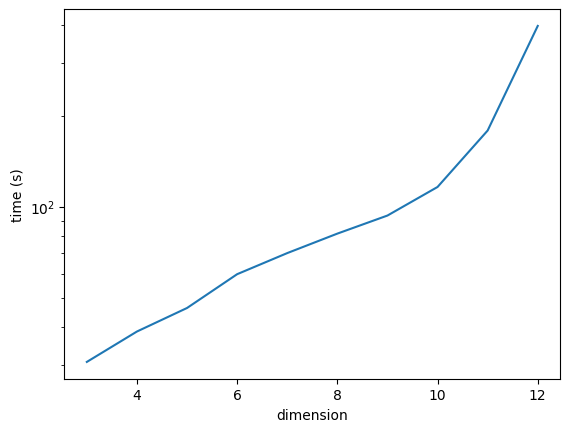

Text(0, 0.5, 'function evaluations')

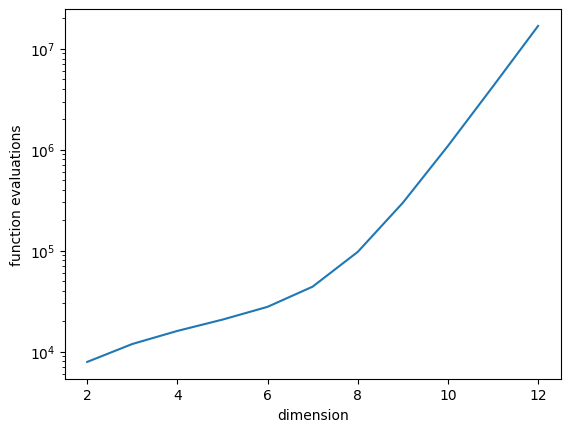

In [18]:
plt.semilogy(dims[1:], times[1:])
plt.xlabel('dimension')
plt.ylabel('time (s)')
plt.show()
plt.semilogy(dims, func_evals)
plt.xlabel('dimension')
plt.ylabel('function evaluations')

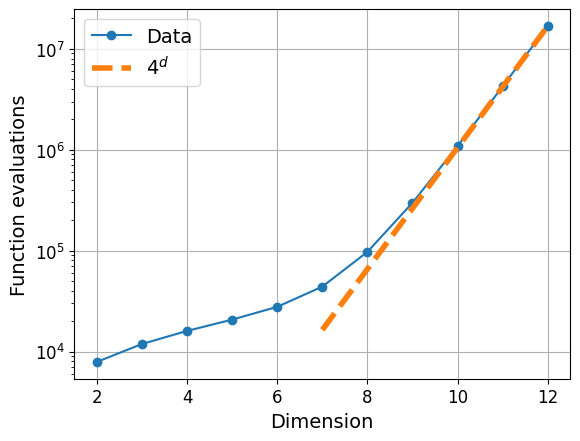

In [71]:
# fit only d = 8,...,12
mask = (dims >= 7)
x = jnp.asarray(dims)[mask]

plt.semilogy(dims, func_evals, 'o-', label='Data')
plt.semilogy(x, 4**x, '--', label='$4^d$', linewidth=4)
# mask = (dims <= 8)
# x = jnp.asarray(dims)[mask]
# plt.semilogy(x, 4800*(4/3)**x, '--', label='$(4/3)^d$', linewidth=2)
# plt.semilogy(dims, 4800*(4/3)**dims+4**dims, '--', label='$(4/3)^d$', linewidth=2)
plt.legend(fontsize=14)
plt.xlabel('Dimension', fontsize=14)
plt.ylabel('Function evaluations', fontsize=14)
plt.tick_params(axis='both', labelsize=12)
plt.grid()
plt.savefig('figs/trig_mix/func_evals.png', dpi=300)

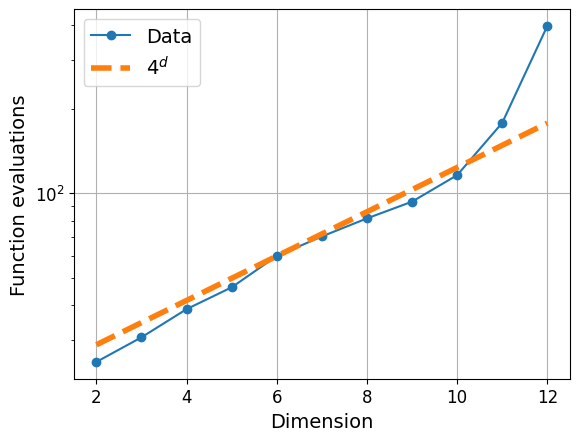

In [90]:
# fit only d = 8,...,12
mask = (dims >= 2)
x = jnp.asarray(dims)[mask]

plt.semilogy(dims, times, 'o-', label='Data')
plt.semilogy(x, 20*(6/5)**x, '--', label='$4^d$', linewidth=4)
plt.legend(fontsize=14)
plt.xlabel('Dimension', fontsize=14)
plt.ylabel('Function evaluations', fontsize=14)
plt.tick_params(axis='both', labelsize=12)
plt.grid()
plt.savefig('figs/trig_mix/time.png', dpi=300)

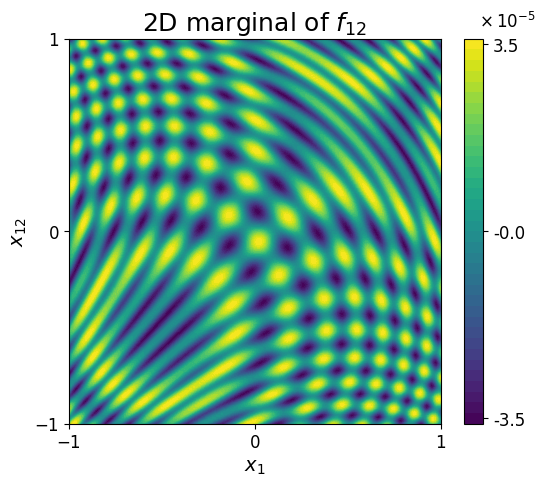

In [60]:
compute_tools.plot_tucker_marginal_2d(approxs[-1],(0,11))
plt.title('2D marginal of $f_{12}$', fontsize=18)
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_{12}$', fontsize=14)

ax = plt.gca()
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=12)

# grab the heatmap image and its colorbar
im = ax.images[0] if ax.images else ax.collections[0]
cbar = im.colorbar

data = im.get_array()
vmin, vmax = data.min(), data.max()
vmean = data.mean()

scale = 1e-5
cbar.set_ticks([vmin, vmean, vmax])
cbar.set_ticklabels([f'{v/scale:.1f}' for v in (vmin, vmean, vmax)])
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_title(r'$\qquad\qquad \times 10^{-5}$', fontsize=12, pad=8)

plt.savefig('figs/trig_mix/12d_marg.png', dpi=300, bbox_inches="tight")

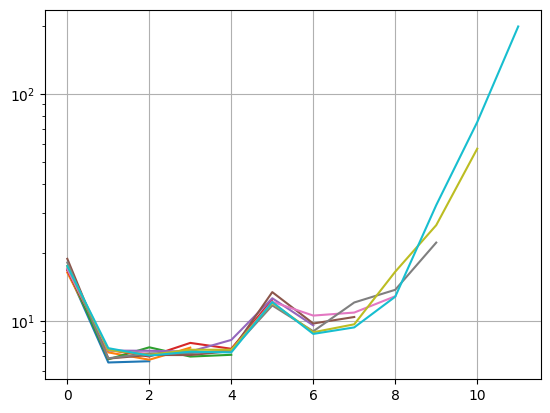

In [110]:
for approx in approxs[1:]:
    plt.semilogy(approx.diagnostics['stage_times_sec'])
plt.grid()

In [122]:
max_error(approxs[10], make_f_trigmix(12), 12, n_test=500)

8.915090887740007e-14

In [119]:
better_errs = []
for d in dims:
    if d%3==0:
        print(d)
    better_errs.append(max_error(approxs[d-2], make_f_trigmix(d), d, n_test=10_000))

KeyboardInterrupt: 

In [ ]:
better_errs

# 4D Airy function NOT IN JAX

Below we consider $g(x_1,x_2,x_3,x_4)=\text{Ai}\bigl(-16(x_1x_4+ x_2x_3)\bigr)$ where Ai is the Airy function
$$
    \text{Ai}(x)=\frac{1}{\pi}\int_0^\infty \cos\left(\frac{t^3}{3}+xt\right)dt.
$$

In [6]:
def _airy_ai_host(z):
    # z arrives as a numpy array here (host callback), already float64
    ai, _, _, _ = sp.airy(z)
    return ai  # don't downcast — keep float64

def airy_ai(z):
    """Ai(z), the Airy function. Wraps scipy.special.airy via a host callback
    since jax.scipy.special has no native Airy implementation."""
    z = jnp.asarray(z, dtype=jnp.float64)  # force float64 before the callback
    out_shape = jax.ShapeDtypeStruct(z.shape, jnp.float64)
    return jax.pure_callback(_airy_ai_host, out_shape, z, vmap_method='broadcast_all')

def f_airy_4d(x):
    x = jnp.asarray(x, dtype=jnp.float64)
    arg = x[:, 0]*x[:, 3] + x[:, 1]*x[:, 2]
    return airy_ai(-8*arg)

# def f_airy_6d(x):
#     x = jnp.asarray(x, dtype=jnp.float64)
#     arg = x[:, 0]*x[:, 5] + x[:, 2]*x[:, 3] + (x[:, 1]*x[:, 4])**2
#     return airy_ai(-10*arg)

In [29]:
r = 38
d = 4
cheb_tol = 1e-7
piv_tol=1e-14
#opts = TuckerOptions(max_rank=r, tucker_update='C', cheb_tol=cheb_tol, n_starts=10, cross_solve_backend="jax", residual_chunk_size=10_000)
opts = TuckerOptions(max_rank=r, tucker_update='C', factor_representation="coeff_tensor", n_starts=40, residual_chunk_size=10_000)
#opts = TuckerOptions(max_rank=r, tucker_update='C', max_cross_cond=1e8,cheb_tol=cheb_tol, n_starts=10, residual_chunk_size=10_000)

start = time.time()
approx = build_chebtucker(f_airy_4d, opts, d=d)
print(time.time()-start)

1494.2554619312286


In [30]:
approx.diagnostics

{'tucker_update': 'C',
 'tucker_rank': 38,
 'factor_representation': 'coeff_tensor',
 'stage_times_sec': [36.62150410100003,
  51.46405237699946,
  115.74042614799691,
  1289.289887551],
 'stage_pivot_counts': [34, 35, 38, 37],
 'stage_cross_cond': [5608956094.380359,
  3478884317.5281305,
  9961667617.706106,
  1074730195.70568],
 'stage_max_abs_U': [577737084.5708379,
  290983384.88128185,
  754748083.5658245,
  40327097.16194839],
 'total_function_value_points': 1689700,
 'core_function_points': 1673140,
 'core_build_time_sec': 0.801312178002263}

In [31]:
start = time.time()
approx(jnp.array([[.1]*d]))
print(time.time()-start)

1.2599260807037354


In [33]:
start = time.time()
print(max_error(approx, f_airy_4d, d, n_test=1000))
print(time.time()-start)

8.85216557833246e-08
2.5837595462799072


In [26]:
approx2 = convert_to_chebfun_tucker(approx, eps=1e-10)

<Axes: title={'center': '2D marginal'}, xlabel='$x_{1}$', ylabel='$x_{4}$'>

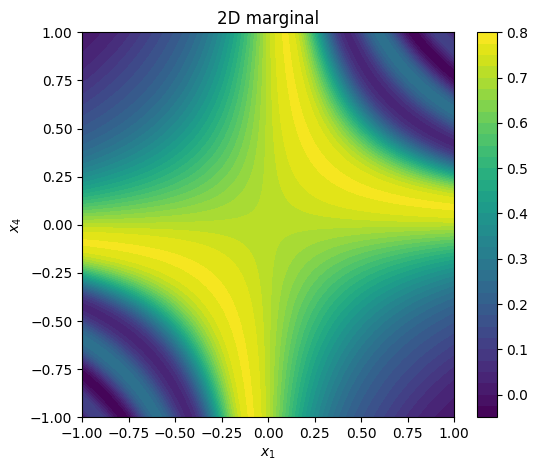

In [27]:
compute_tools.plot_tucker_marginal_2d(approx2,(0,3))

In [ ]:
ranks = jnp.arange(2, 39, 2)
d = 4
max_errs = []
times = []
approxs = []
func_evals = []
for r in ranks:
    opts = TuckerOptions(max_rank=r, tucker_update='C', factor_representation="coeff_tensor", n_starts=40, residual_chunk_size=10_000)
    start = time.time()
    approx = build_chebtucker(f_airy_4d, opts, d=d)
    t = time.time()-start
    times.append(t)
    max_err = max_error(approx, f_airy_4d, d, n_test=1000)
    max_errs.append(max_err)
    approxs.append(approx)
    func_evals.append(approx.diagnostics['total_function_value_points'])
    if r%4==0:
        print(f'rank {r} took {t:.1f} s, has error {max_err:.3g}')

rank 4 took 18.6 s, has error 0.844
rank 8 took 40.9 s, has error 1.18
rank 12 took 51.9 s, has error 1.13
rank 16 took 79.5 s, has error 1.14
rank 20 took 126.0 s, has error 0.744
rank 24 took 229.9 s, has error 0.00847
rank 28 took 426.7 s, has error 0.000647
rank 32 took 691.1 s, has error 3.84e-06
rank 36 took 1094.1 s, has error 3.6e-07


# some jax.scipy.special functions

In [ ]:
@jax.jit
def f_wofz(x):
    z = x[:,0]*x[:,3] + x[:,1]*x[:,2]
    arg = 4*z + 2*z**3
    return jnp.real(js.wofz(-5*arg))
    
def f_fresnel(x):
    x = jnp.asarray(x, dtype=jnp.float64)
    arg = x[:,0]*x[:,3] + x[:,1]*x[:,2]
    S, C = js.fresnel(8*arg)
    return S

In [ ]:
r = 25
d = 4
cheb_tol = 1e-12

opts = TuckerOptions(
    max_rank=r,
    tucker_update='C',
    factor_representation="coeff_tensor",
    # cheb_tol=cheb_tol,
    n_starts=10,
    residual_chunk_size=10_000,
    gd_steps=20,
    gd_lr=0.05,
    gd_method='adam',
    optimizer_objective='square',
)
start = time.time()
approx = build_chebtucker(f_wofz, opts, d=d)
print(time.time()-start)

In [ ]:
approx.diagnostics

In [ ]:
start = time.time()
print(max_error(approx, f_wofz, d, n_test=1000))
print(time.time()-start)

In [ ]:
approx2 = convert_to_chebfun_tucker(approx, eps=1e-10)

In [ ]:
compute_tools.plot_tucker_marginal_2d(approx2,(0,3))

In [ ]:
r = 15
d = 4
cheb_tol = 1e-12

opts = TuckerOptions(
    max_rank=r,
    tucker_update='C',
    factor_representation="coeff_tensor",
    # cheb_tol=cheb_tol,
    n_starts=10,
    residual_chunk_size=10_000,
    gd_steps=10,
    gd_lr=0.05,
    gd_method='adam',
    optimizer_objective='square',
)
start = time.time()
approx_fresnel = build_chebtucker(f_fresnel, opts, d=d)
print(time.time()-start)

In [ ]:
start = time.time()
print(max_error(approx_fresnel, f_fresnel, d, n_test=1000))
print(time.time()-start)

In [ ]:
approx_fresnel = convert_to_chebfun_tucker(approx_fresnel, eps=1e-10)

In [ ]:
compute_tools.plot_tucker_marginal_2d(approx_fresnel,(0,3))